In [1]:
### import os
import sys

sys.path.append("../src")


from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as spy
import seaborn as sns
import sklearn as sk
from ExoModel.nuc_template_constants import ExoNucTemplate
from tqdm.auto import tqdm

/trinity/home/d_ryabov/.conda/envs/newNucDPosIT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
bed_fields = ["ref", "start", "stop", "win", "height"]

name = "SRR1802185"
# name = "SRR1258922"

BED_PATH = f"../data/nuc_maped/refator_runs/{name}/dyads.bed"


templates_fields = ["start", "stop", "dyad", "pr", "ref"]
TEMAPLTES_PATH = f"../data/nuc_maped/refator_runs/{name}/templates.csv"

SAVEFIG_DIR = f"../data/figs/tmp/{name}"
!mkdir {SAVEFIG_DIR}


def read_bed(path, bed_fields, *args, **kwargs):
    df = pd.read_csv(path, header=None, sep="\t", names=bed_fields)
    return df


def read_srr(path, srr_fields, *args, **kwargs):
    df = pd.read_csv(path, header=None, names=srr_fields)
    return df


dyads_df = read_bed(BED_PATH, bed_fields)
templates_df = read_srr(TEMAPLTES_PATH, templates_fields)

mkdir: cannot create directory ‘../data/figs/tmp/SRR1802185’: File exists


<Axes: >

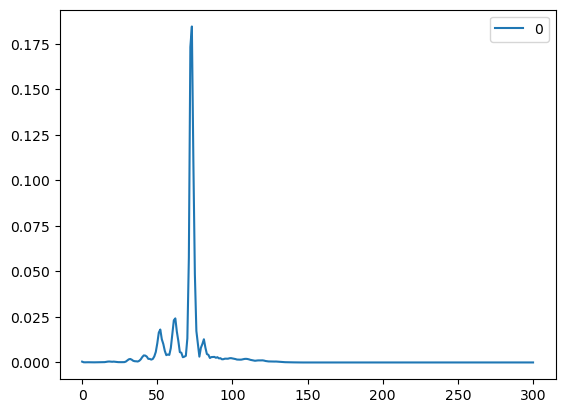

In [3]:
ERROR_PATH = f"../data/reads/S_cerevisiae/{name}/exomodel_results/errors.csv"
ERRORS = pd.read_csv(ERROR_PATH, header=None)
ERRORS.plot()

In [4]:
from EMmodel.functools import fit_model_template, make_occupancy

e = ERRORS.to_numpy().flatten()
e /= e.sum()

template = fit_model_template(e)

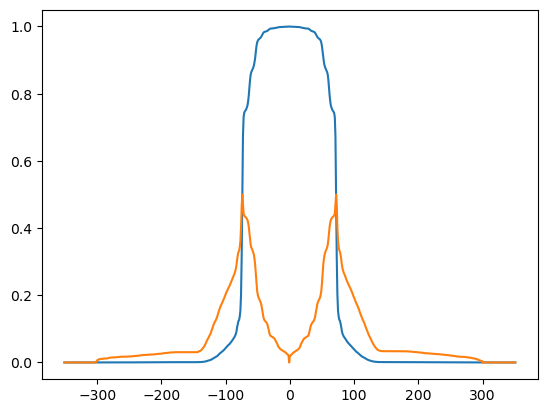

In [5]:
x = np.arange(len(template)) - len(template) // 2
plt.plot(x, template)


ntries = 1
std_dev = np.sqrt(ntries * template * (1 - template))
plt.plot(x, std_dev)

/tmp/d_ryabov.4599/ipykernel_1657095/1164219897.py:32: RuntimeWarning: divide by zero encountered in power
  * (1 - prob) ** (ntries - nsuccess)
/tmp/d_ryabov.4599/ipykernel_1657095/1164219897.py:30: RuntimeWarning: invalid value encountered in multiply
  scipy.special.binom(ntries, nsuccess)


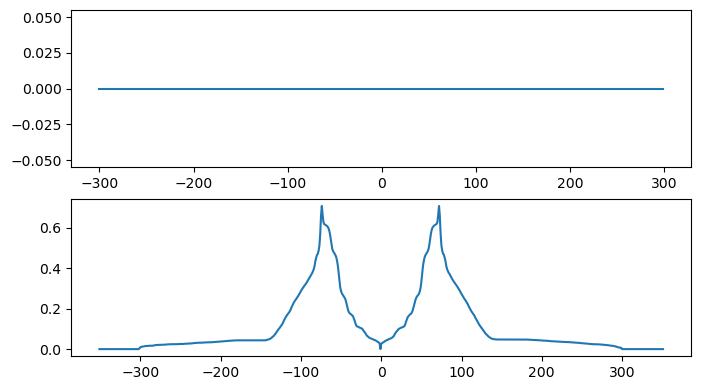

In [28]:
import scipy.special

def binary_search(arr, target):
    left = 0
    right = len(arr) - 1
    
    while left <= right:
        mid = (left + right) // 2  # Индекс среднего элемента
        
        if arr[mid] == target:
            return mid  # Элемент найден, возвращаем его индекс
        elif arr[mid] < target:
            left = mid + 1  # Искомый элемент больше среднего, сдвигаем левую границу
        else:
            right = mid - 1  # Искомый элемент меньше среднего, сдвигаем правую границу
            
    return np.nan


def model_profile(x, y, nsuccess, ntries):
    template_x = np.arange(len(y)) - len(y) // 2
    mask = np.array([binary_search(template_x, xi) for xi in x])
    
    valid_mask = ~np.isnan(mask)
    
    prob = y[mask[valid_mask].astype(int)]

    
    profile = (
        scipy.special.binom(ntries, nsuccess)
        * (prob**nsuccess)
        * (1 - prob) ** (ntries - nsuccess)
    )

    # plt.plot(profile)

    # profile_y = np.zeros_like(x)
    # profile_y[~np.isnan(mask)] = profile
    
    return profile


x = np.arange(-300, 300)
# x = np.array([98, 99, 100, 700])
nsuccess = 4
ntries = 2


my = model_profile(x, template, nsuccess, ntries)

std_dev = np.sqrt(ntries * template * (1 - template))
template_x = np.arange(len(template)) - len(template) // 2

fig, axs = plt.subplots(2, 1, figsize=(8, 4.5))
axs[0].plot(x, my)
axs[1].plot(template_x, std_dev)

,start,stop,pr,ref
dyad,,,,
52084,24,24,24,24
52095,39,39,39,39
52119,8,8,8,8
52134,30,30,30,30
52166,36,36,36,36
...,...,...,...,...
54805,20,20,20,20
54873,4,4,4,4
54942,11,11,11,11


In [36]:
centers = (q['start'] + q['stop']) // 2
center_dict = Counter(centers.value_counts().to_dict())

center_bins = [center_dict[xi] for xi in x]

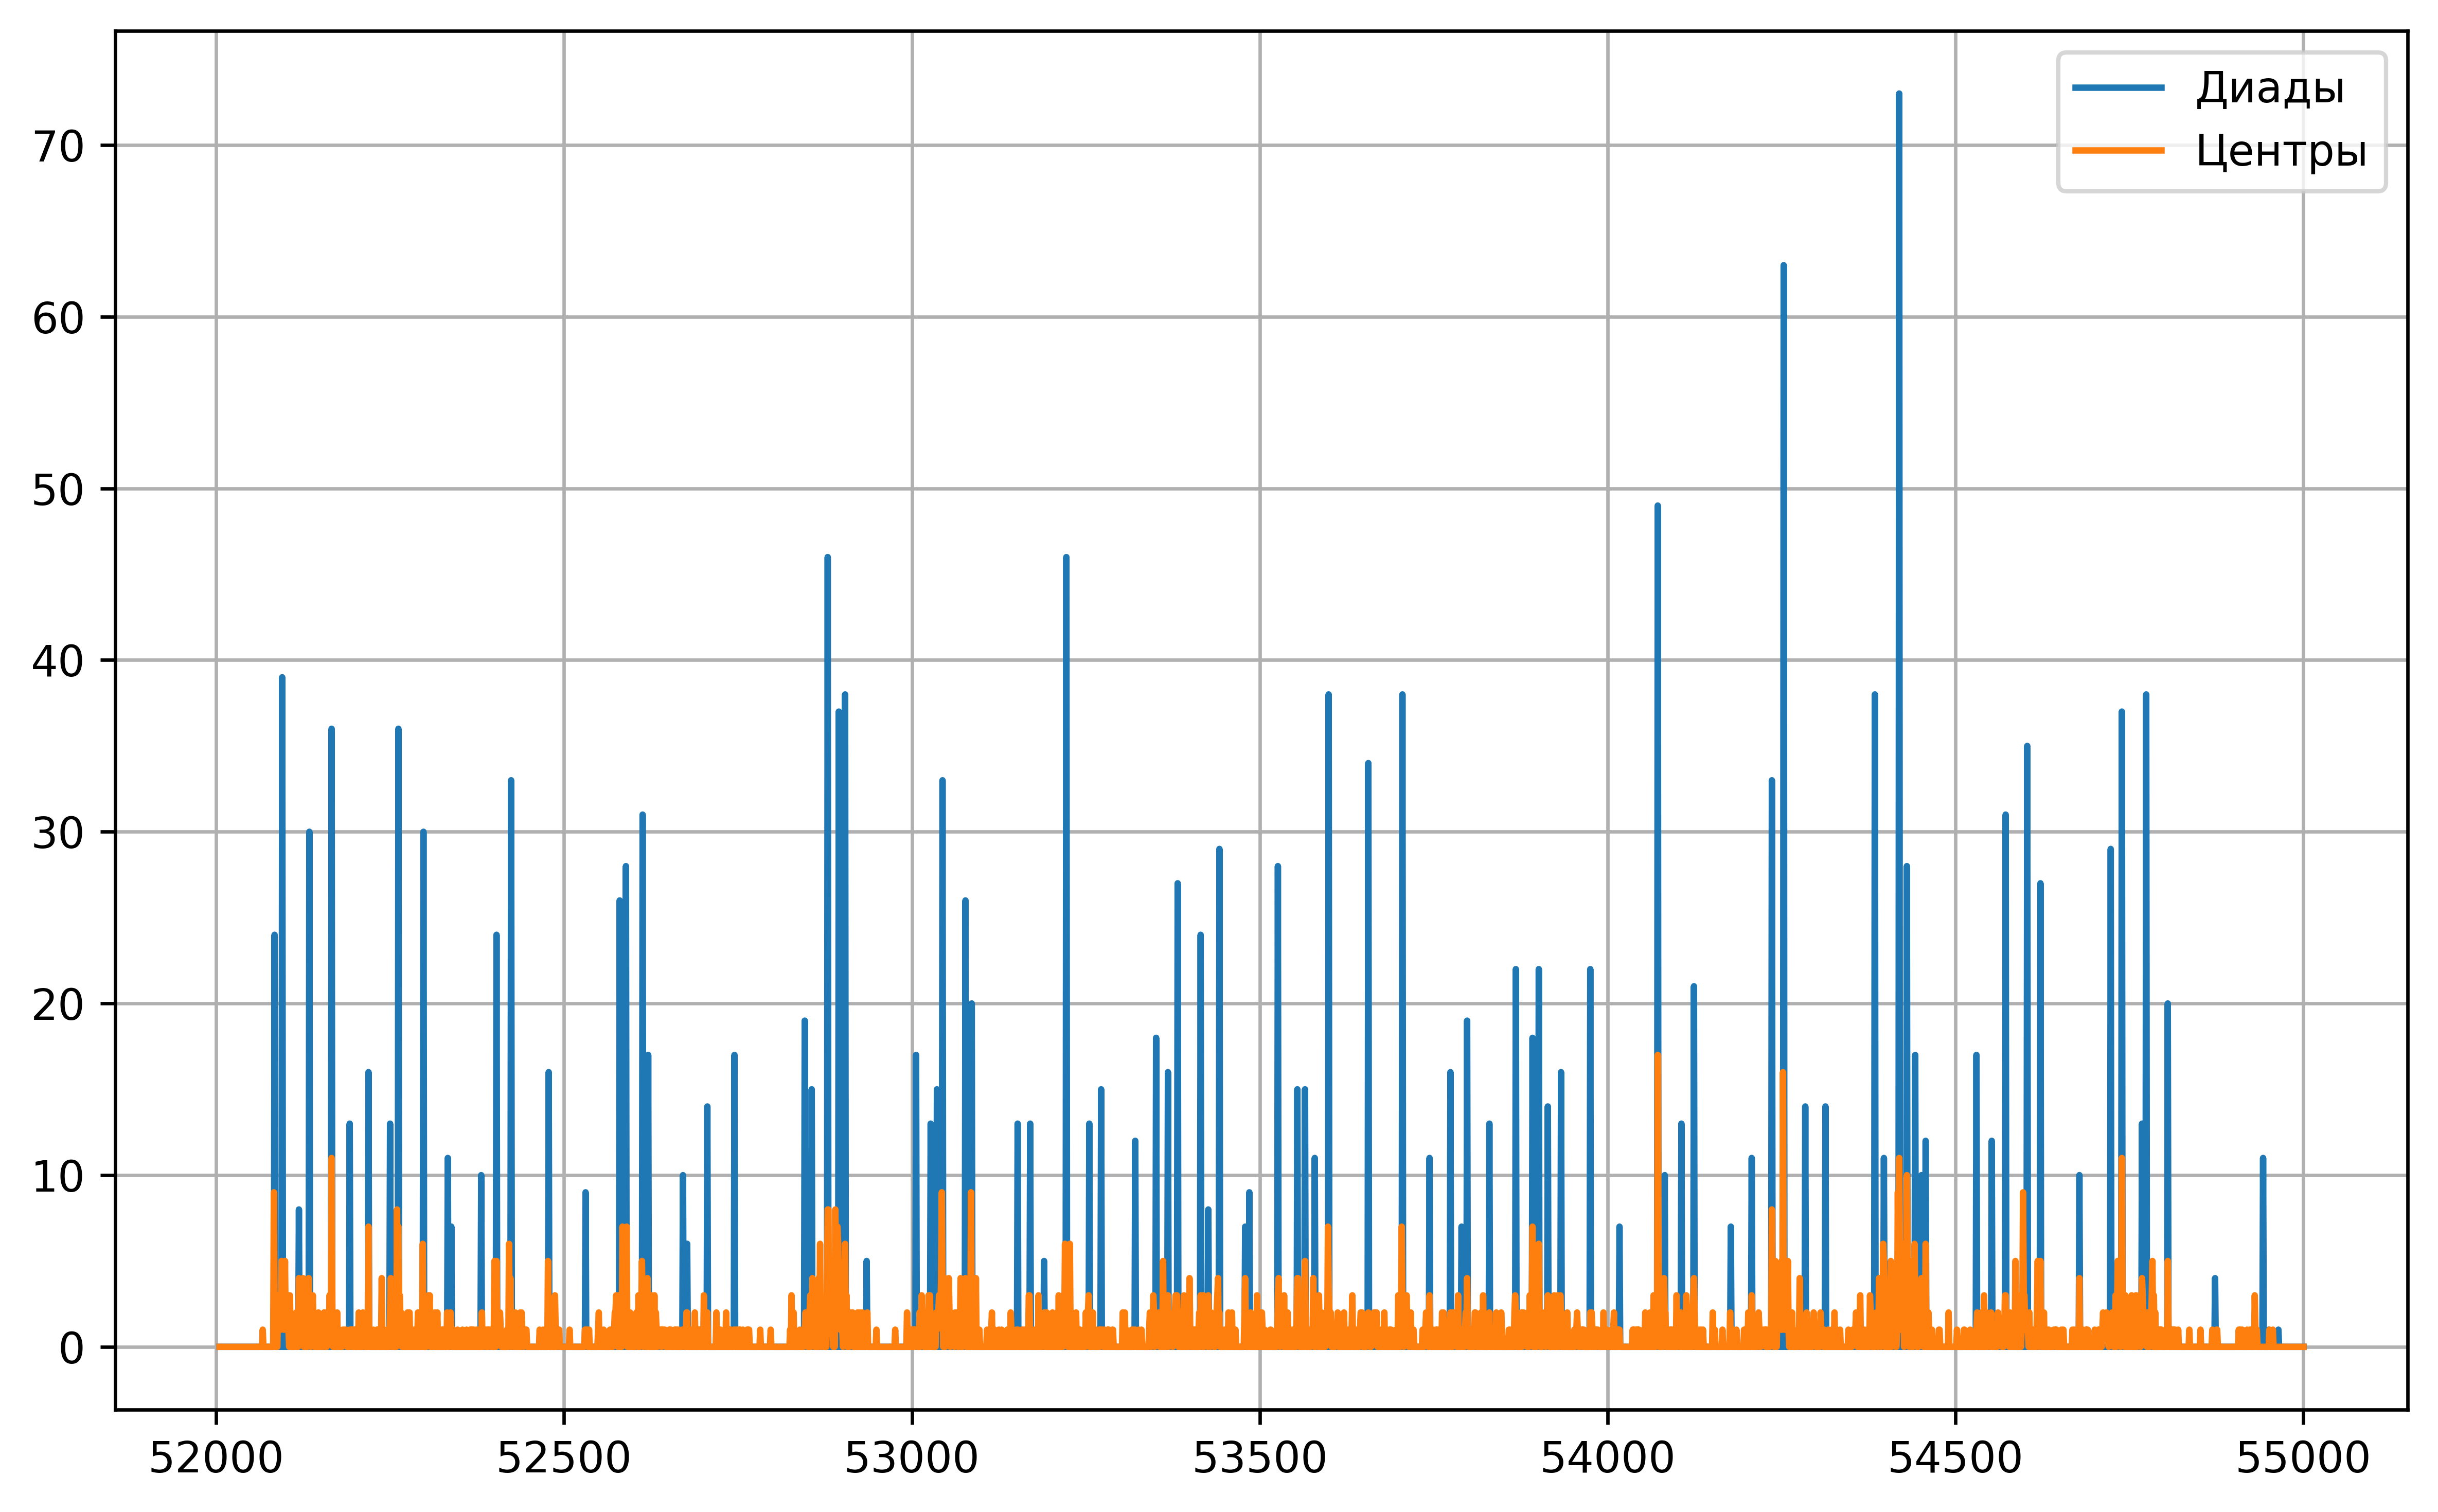

In [39]:
qstart = 52000
qstop = 55000

q = templates_df.query('ref == "NC_001133.9"').query(
    "start >= @qstart and stop <= @qstop"
)
x, y = make_occupancy(q.start, q.stop)

dyad_dict = Counter(q.dyad.value_counts().to_dict())
dyad_bins = [dyad_dict[xi] for xi in x]

model_occ = np.convolve(dyad_bins, template, "same")


plt.figure(figsize=(8, 5), dpi=600)

# plt.plot(x, y, label="Эксперимент")
plt.plot(x, dyad_bins, label="Диады")
# plt.plot(x, model_occ, label="Модель")

plt.plot(x, center_bins, label='Центры')

plt.grid()

plt.legend()
plt.tight_layout()

# plt.savefig(f"{name}_nuc_occ.png")

In [322]:
std_dev_profile = np.zeros_like(x, dtype=float)
pad_len = 500
std_dev_profile = np.pad(std_dev_profile, pad_len)

for dyad, ntries in q.groupby('dyad')['start'].count().to_dict().items():
    std_dev = ntries * template * (1 - template)

    dyad_idx = binary_search(x, dyad) + pad_len
    start_idx = dyad_idx - len(std_dev) // 2
    stop_idx = dyad_idx + len(std_dev) // 2
    std_dev_profile[start_idx : stop_idx] += std_dev

std_dev_profile = std_dev_profile[500 : -500]

/tmp/d_ryabov.4578/ipykernel_1454574/2905160933.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


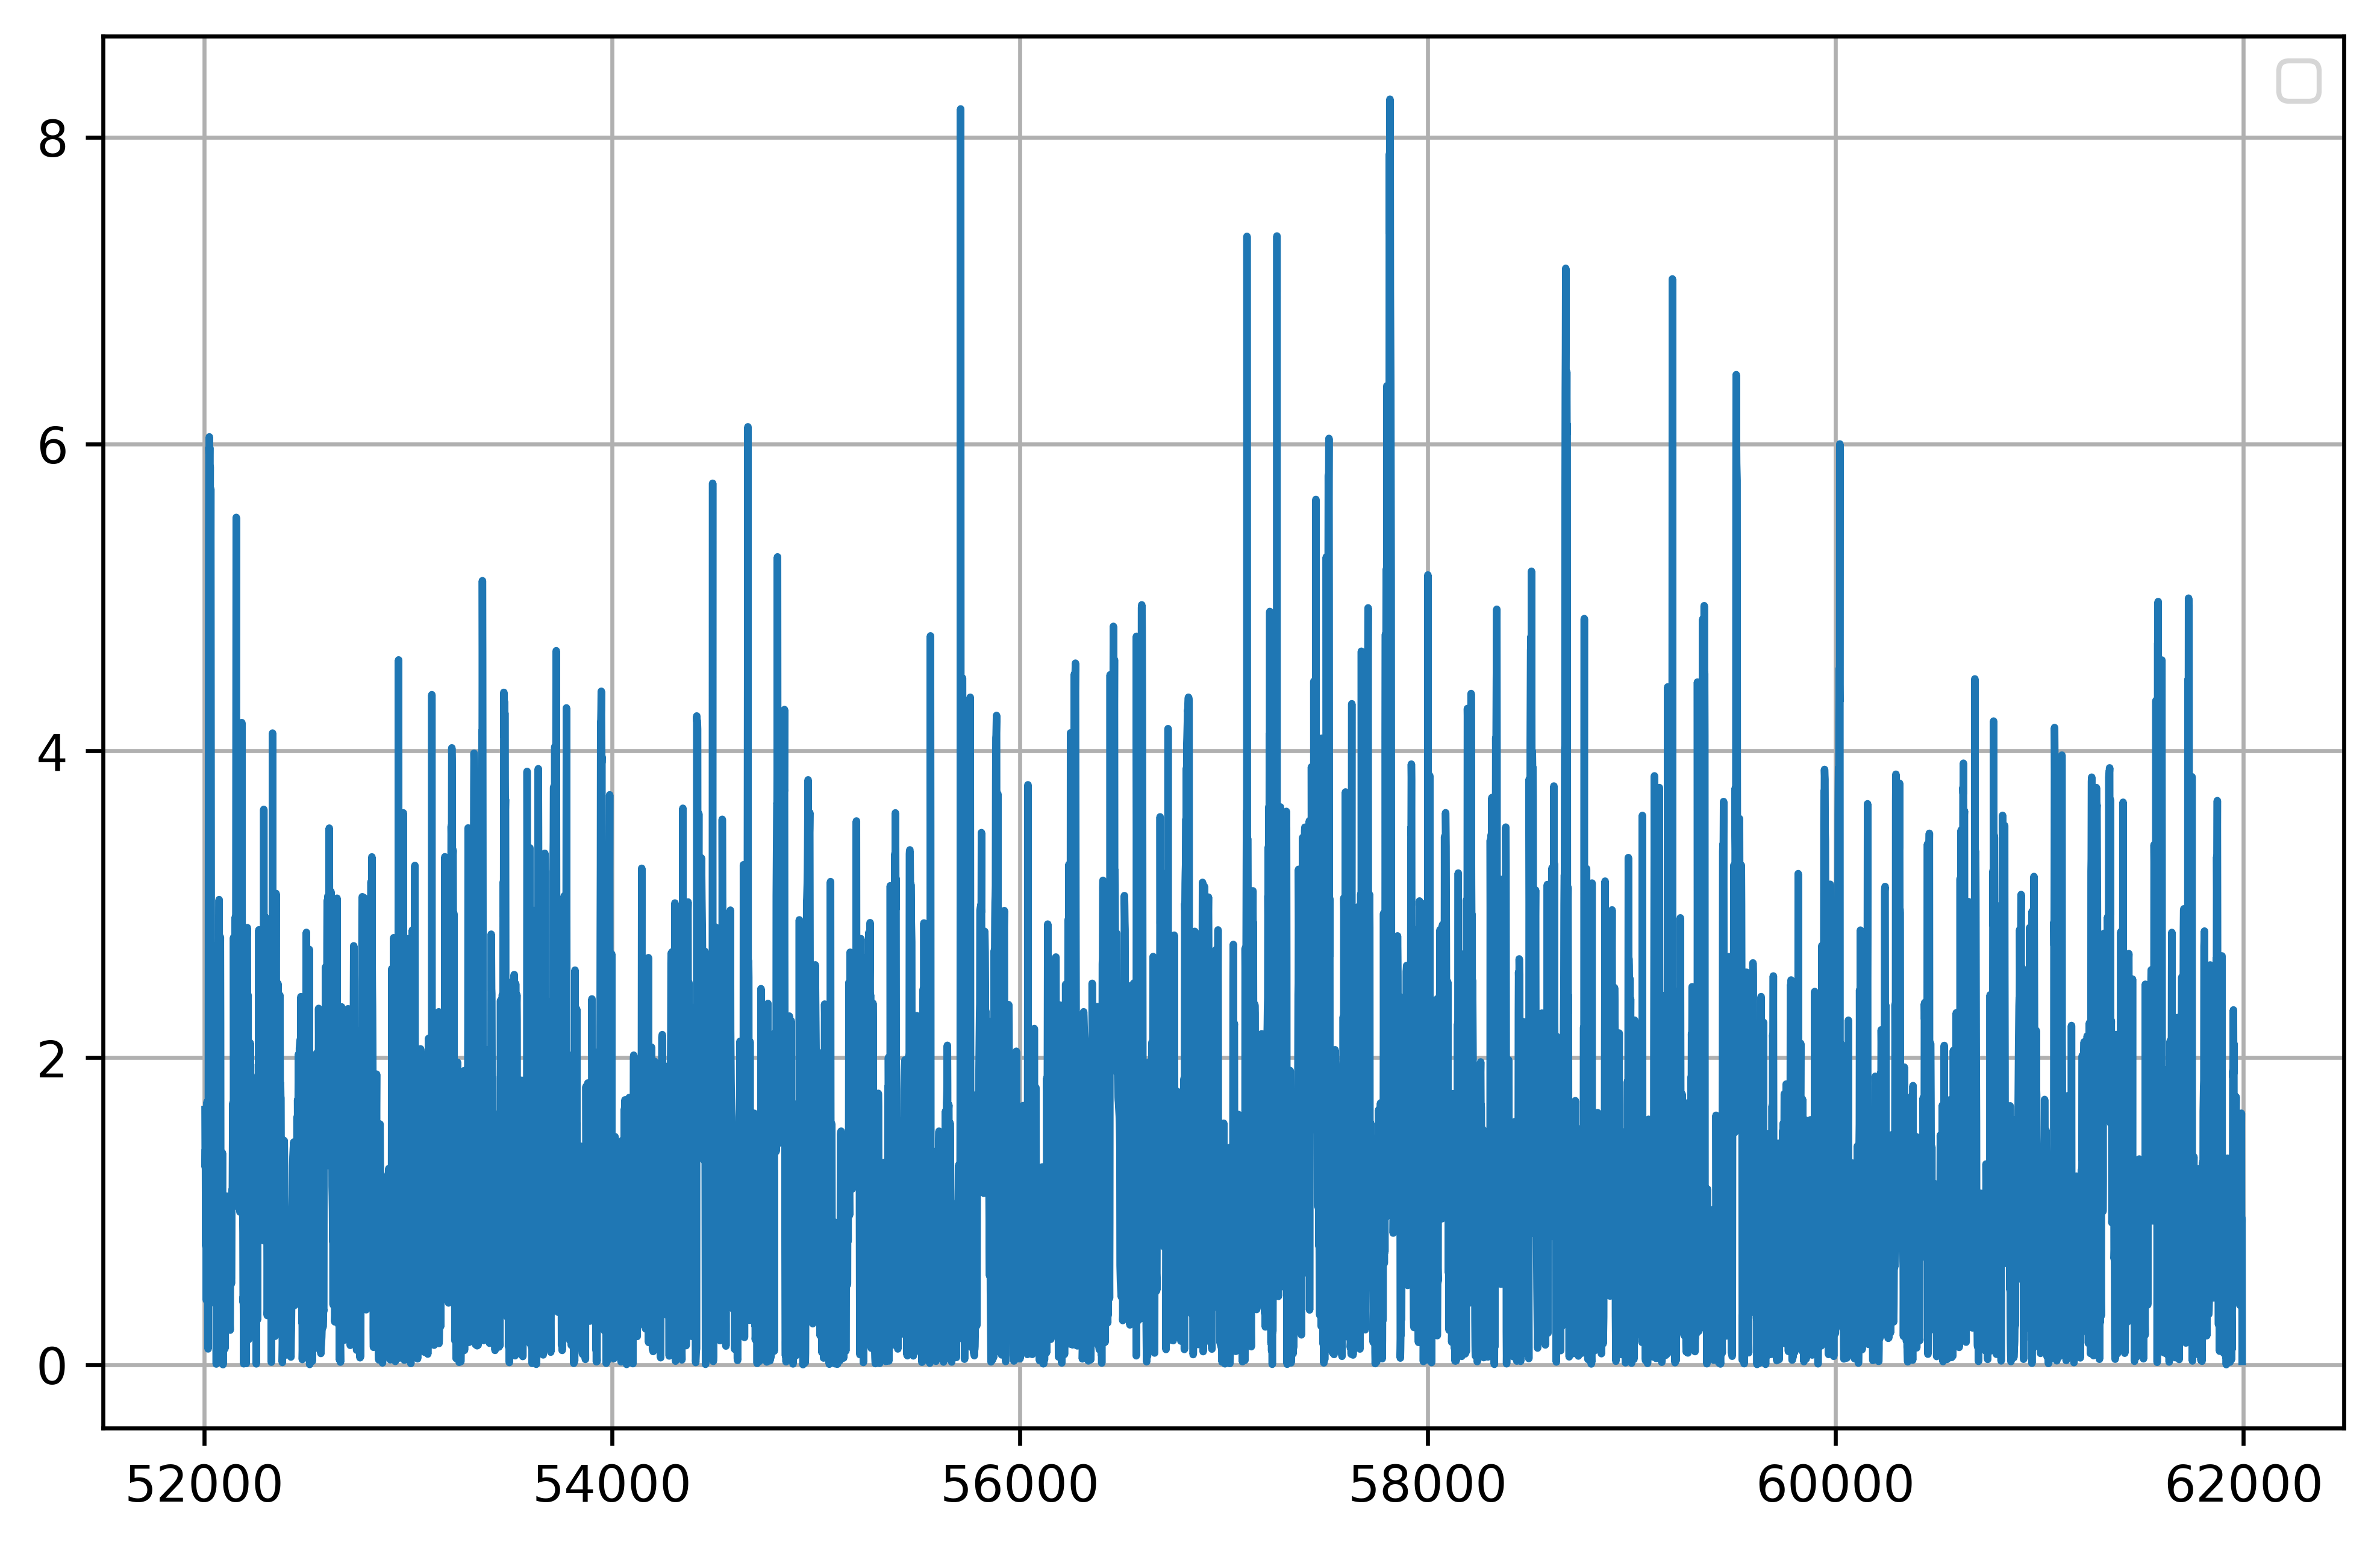

In [325]:
plt.figure(figsize=(8, 5), dpi=600)
# plt.plot(x, std_dev_profile, label='sigma2')

sigma_relative = np.sqrt((y - model_occ) ** 2 / std_dev_profile)

plt.plot(x, sigma_relative)

# plt.plot(x, y, label="Эксперимент")
# plt.plot(x, dyad_bins, label="Диады")
# plt.plot(x, model_occ, label="Модель")
plt.grid()

plt.legend()

<Axes: ylabel='Count'>

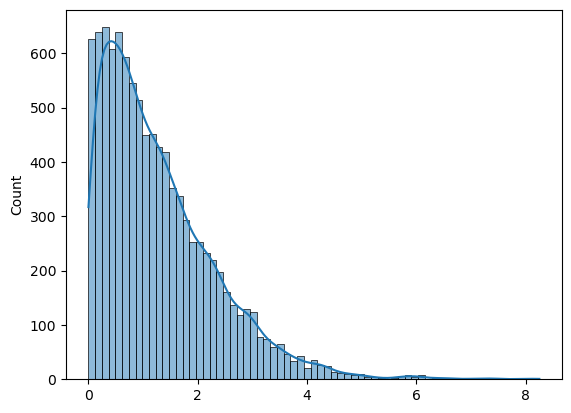

In [326]:
sns.histplot(sigma_relative, kde=True)

In [278]:
len(std_dev) // 2

350